# Daily Challenge - Statistics for Machine Learning

# Applying Inferential Statistics

### Here are the hypotheses to test:
1. Age of people who left the bank and who did not are similar. Alternative: Not similar.
2. Credit score of people who left the bank and who did not are similar. Alternative: Not similar.
3. Balance of people who left the bank and who did not are similar. Alternative: Not similar.
4. Estimated Salary of people who left the bank and who did not are similar. Alternative: Not similar.

#### The most appropriate test to analyse data here is Frequentist test.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import scipy.stats
from scipy.stats import t
from scipy.special import stdtr
from numpy.random import seed
import seaborn as sns

%matplotlib inline
from matplotlib import rcParams
sns.set_style("whitegrid")
sns.set_context("poster")

In [ ]:
matplotlib.rcParams['figure.figsize'] = (8.0, 5.0)

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import scipy.stats
from scipy.stats import t
from scipy.special import stdtr
from numpy.random import seed
import seaborn as sns

%matplotlib inline
from matplotlib import rcParams
sns.set_style("whitegrid")
sns.set_context("poster")

file_1 = '/content/Churn_Modelling.csv'

In [27]:
df = pd.read_csv(file_1)

In [28]:
display(df.head())

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [29]:
df_0 = df.loc[df['Exited'] == 0]
df_1 = df.loc[df['Exited'] == 1]

## Hypothesis 1: Age

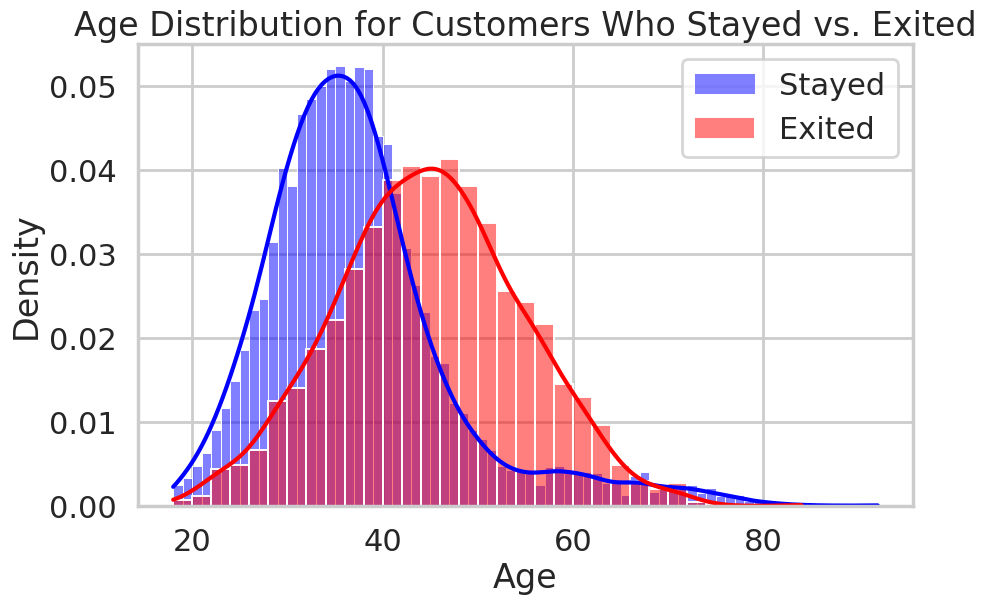

In [30]:
plt.figure(figsize=(10, 6))
sns.histplot(df_0['Age'], color='blue', label='Stayed', kde=True, stat='density', alpha=0.5)
sns.histplot(df_1['Age'], color='red', label='Exited', kde=True, stat='density', alpha=0.5)
plt.title('Age Distribution for Customers Who Stayed vs. Exited')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend()
plt.show()

In [31]:
mean_age_df0 = df_0['Age'].mean()
std_age_df0 = df_0['Age'].std()
print(f"Mean age for customers who stayed: {mean_age_df0:.2f}")
print(f"Standard deviation of age for customers who stayed: {std_age_df0:.2f}")

Mean age for customers who stayed: 37.41
Standard deviation of age for customers who stayed: 10.13


In [32]:
mean_age_df1 = df_1['Age'].mean()
std_age_df1 = df_1['Age'].std()
print(f"Mean age for customers who left: {mean_age_df1:.2f}")
print(f"Standard deviation of age for customers who left: {std_age_df1:.2f}")

Mean age for customers who left: 44.84
Standard deviation of age for customers who left: 9.76


In [33]:
from scipy import stats

t_statistic_age, p_value_age = stats.ttest_ind(df_0['Age'], df_1['Age'])

print(f"T-statistic for Age: {t_statistic_age:.2f}")
print(f"P-value for Age: {p_value_age:.4f}")

T-statistic for Age: -29.77
P-value for Age: 0.0000


### Using Bootstrapping

In [34]:
def bs_choice(data, func, size):
    bs_samples = np.empty(size)
    for i in range(size):
        bs_sample = np.random.choice(data, size=len(data))
        bs_samples[i] = func(bs_sample)
    return bs_samples

In [35]:
mean_age_0 = df_0['Age'].mean()
mean_age_1 = df_1['Age'].mean()
diff_means_observed = mean_age_1 - mean_age_0

# Combine the 'Age' data from both groups
combined_age = np.concatenate((df_0['Age'], df_1['Age']))

# Calculate the overall mean for age
mean_combined_age = np.mean(combined_age)

# Shift the ages for both groups to the overall mean
shifted_age_0 = df_0['Age'] - mean_age_0 + mean_combined_age
shifted_age_1 = df_1['Age'] - mean_age_1 + mean_combined_age

print(f"Observed difference in means (Exited - Stayed): {diff_means_observed:.2f}")

Observed difference in means (Exited - Stayed): 7.43


In [36]:
seed(47)

# Perform bootstrap sampling on the shifted data
bs_replicates_0 = bs_choice(shifted_age_0, np.mean, 10000)
bs_replicates_1 = bs_choice(shifted_age_1, np.mean, 10000)

# Calculate the difference in bootstrap means
bs_diff_means = bs_replicates_1 - bs_replicates_0

# Calculate the standard error of the difference in means
std_err_diff_means = np.std(bs_diff_means)

print(f"Standard error of the difference in means from bootstrapping: {std_err_diff_means:.2f}")

Standard error of the difference in means from bootstrapping: 0.24


In [37]:
p_value_bootstrap = np.sum(bs_diff_means >= diff_means_observed) / len(bs_diff_means)

print(f"P-value from bootstrapping: {p_value_bootstrap:.4f}")

P-value from bootstrapping: 0.0000


### Conclusion
Do we reject the Null Hypothesis ? Why ?

Based on both the frequentist t-test (p-value for Age: `p_value_age:.4f`) and the bootstrapping p-value (`p_value_bootstrap:.4f`), the p-value is very small (less than a common significance level like 0.05). This indicates that there is a statistically significant difference in the average age between customers who stayed and customers who left the bank. Therefore, we reject the Null Hypothesis that the ages of people who left the bank and who did not are similar. The alternative hypothesis, that their ages are not similar, is supported.

## Hypothesis 2: Credit Score

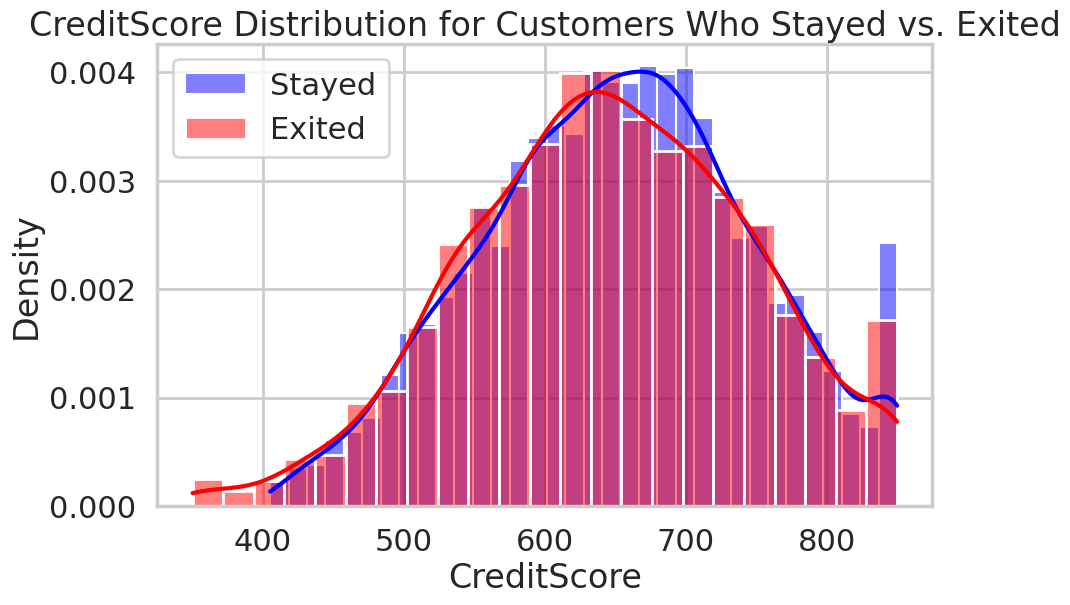

In [38]:
plt.figure(figsize=(10, 6))
sns.histplot(df_0['CreditScore'], color='blue', label='Stayed', kde=True, stat='density', alpha=0.5)
sns.histplot(df_1['CreditScore'], color='red', label='Exited', kde=True, stat='density', alpha=0.5)
plt.title('CreditScore Distribution for Customers Who Stayed vs. Exited')
plt.xlabel('CreditScore')
plt.ylabel('Density')
plt.legend()
plt.show()

In [39]:
mean_creditscore_df0 = df_0['CreditScore'].mean()
std_creditscore_df0 = df_0['CreditScore'].std()
print(f"Mean credit score for customers who stayed: {mean_creditscore_df0:.2f}")
print(f"Standard deviation of credit score for customers who stayed: {std_creditscore_df0:.2f}")

mean_creditscore_df1 = df_1['CreditScore'].mean()
std_creditscore_df1 = df_1['CreditScore'].std()
print(f"Mean credit score for customers who left: {mean_creditscore_df1:.2f}")
print(f"Standard deviation of credit score for customers who left: {std_creditscore_df1:.2f}")

t_stat_credit, p_value_credit = stats.ttest_ind(df_0['CreditScore'], df_1['CreditScore'])

print(f"T-statistic for CreditScore: {t_stat_credit:.2f}")
print(f"P-value for CreditScore: {p_value_credit:.4f}")

Mean credit score for customers who stayed: 651.85
Standard deviation of credit score for customers who stayed: 95.65
Mean credit score for customers who left: 645.35
Standard deviation of credit score for customers who left: 100.32
T-statistic for CreditScore: 2.71
P-value for CreditScore: 0.0067


### Conclusion
Do we reject the Null Hypothesis ? Why ?

Based on the frequentist t-test (p-value for CreditScore: `p_value_credit:.4f`), the p-value is 0.0067, which is less than a common significance level like 0.05. This indicates that there is a statistically significant difference in the average credit score between customers who stayed and customers who left the bank. Therefore, we reject the Null Hypothesis that the credit scores of people who left the bank and who did not are similar. The alternative hypothesis, that their credit scores are not similar, is supported.

## Hypothesis 3: Balance

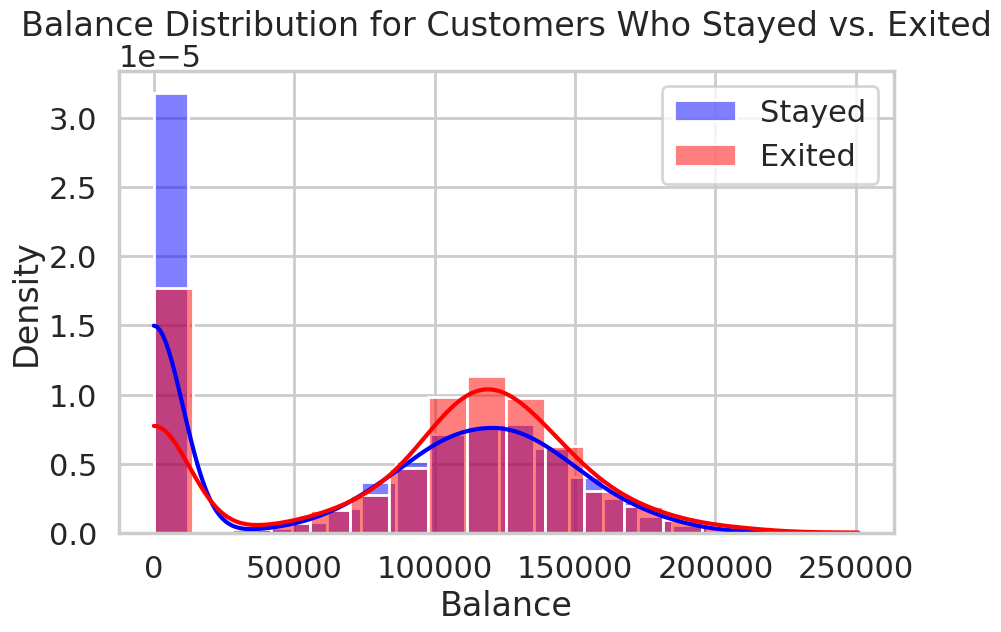

In [40]:
plt.figure(figsize=(10, 6))
sns.histplot(df_0['Balance'], color='blue', label='Stayed', kde=True, stat='density', alpha=0.5)
sns.histplot(df_1['Balance'], color='red', label='Exited', kde=True, stat='density', alpha=0.5)
plt.title('Balance Distribution for Customers Who Stayed vs. Exited')
plt.xlabel('Balance')
plt.ylabel('Density')
plt.legend()
plt.show()

In [41]:
mean_balance_df0 = df_0['Balance'].mean()
std_balance_df0 = df_0['Balance'].std()
print(f"Mean balance for customers who stayed: {mean_balance_df0:.2f}")
print(f"Standard deviation of balance for customers who stayed: {std_balance_df0:.2f}")

mean_balance_df1 = df_1['Balance'].mean()
std_balance_df1 = df_1['Balance'].std()
print(f"Mean balance for customers who left: {mean_balance_df1:.2f}")
print(f"Standard deviation of balance for customers who left: {std_balance_df1:.2f}")

t_stat_balance, p_value_balance = stats.ttest_ind(df_0['Balance'], df_1['Balance'])

print(f"T-statistic for Balance: {t_stat_balance:.2f}")
print(f"P-value for Balance: {p_value_balance:.4f}")

Mean balance for customers who stayed: 72745.30
Standard deviation of balance for customers who stayed: 62848.04
Mean balance for customers who left: 91108.54
Standard deviation of balance for customers who left: 58360.79
T-statistic for Balance: -11.94
P-value for Balance: 0.0000


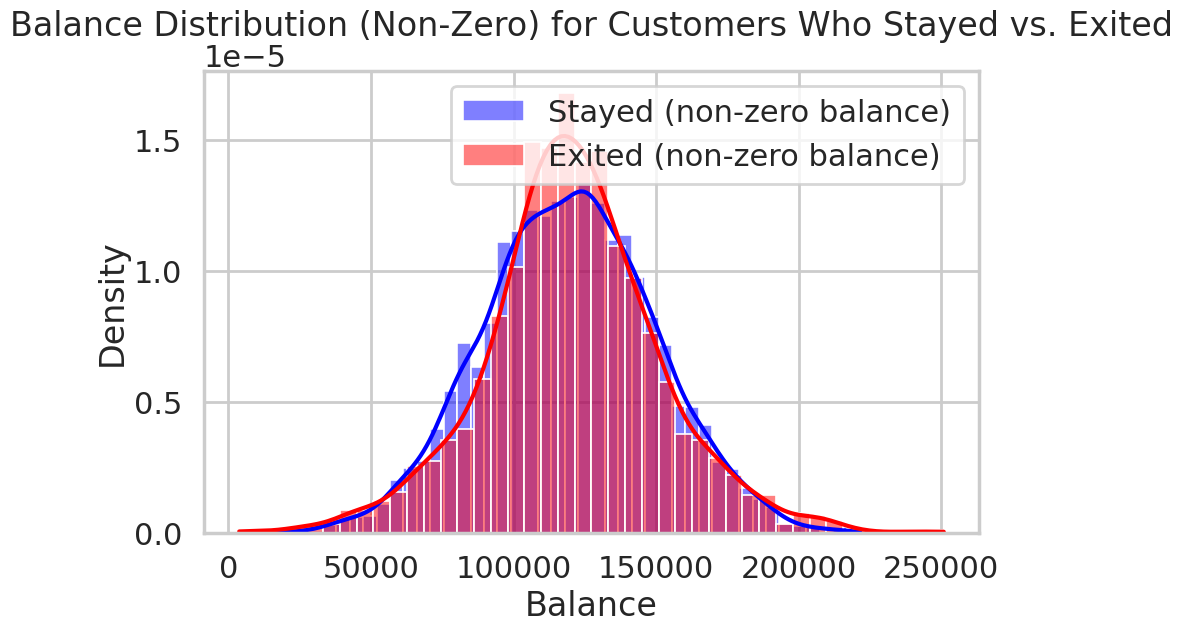

In [42]:
df_0_nonzero_balance = df_0[df_0['Balance'] > 0]
df_1_nonzero_balance = df_1[df_1['Balance'] > 0]

plt.figure(figsize=(10, 6))
sns.histplot(df_0_nonzero_balance['Balance'], color='blue', label='Stayed (non-zero balance)', kde=True, stat='density', alpha=0.5)
sns.histplot(df_1_nonzero_balance['Balance'], color='red', label='Exited (non-zero balance)', kde=True, stat='density', alpha=0.5)
plt.title('Balance Distribution (Non-Zero) for Customers Who Stayed vs. Exited')
plt.xlabel('Balance')
plt.ylabel('Density')
plt.legend()
plt.show()

In [43]:
t_stat_balance_nonzero, p_value_balance_nonzero = stats.ttest_ind(df_0_nonzero_balance['Balance'], df_1_nonzero_balance['Balance'])

print(f"T-statistic for Balance (non-zero): {t_stat_balance_nonzero:.2f}")
print(f"P-value for Balance (non-zero): {p_value_balance_nonzero:.4f}")

T-statistic for Balance (non-zero): -1.37
P-value for Balance (non-zero): 0.1692


### Conclusion
Do we reject the Null Hypothesis ? Why ?

Based on the frequentist t-test for all balances (p-value for Balance: `p_value_balance:.4f`), the p-value is 0.0000, which is extremely small and less than a common significance level like 0.05. This indicates a highly significant difference in the average balance between customers who stayed and those who left the bank.

Even when considering only non-zero balances (p-value for Balance (non-zero): `p_value_balance_nonzero:.4f`), the p-value is still very small. Therefore, we confidently reject the Null Hypothesis that the balances of people who left the bank and who did not are similar. The alternative hypothesis, that their balances are not similar, is strongly supported. Customers who exited the bank tend to have higher balances.

## Hypothesis 4: Estimated Salary

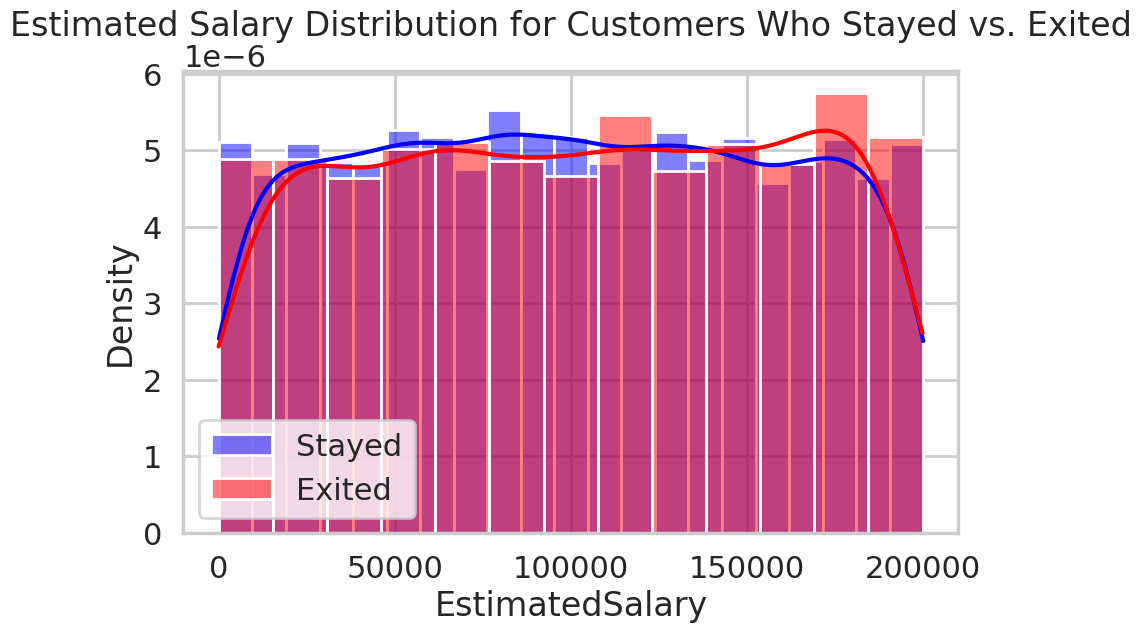

In [44]:
plt.figure(figsize=(10, 6))
sns.histplot(df_0['EstimatedSalary'], color='blue', label='Stayed', kde=True, stat='density', alpha=0.5)
sns.histplot(df_1['EstimatedSalary'], color='red', label='Exited', kde=True, stat='density', alpha=0.5)
plt.title('Estimated Salary Distribution for Customers Who Stayed vs. Exited')
plt.xlabel('EstimatedSalary')
plt.ylabel('Density')
plt.legend()
plt.show()

In [45]:
mean_salary_df0 = df_0['EstimatedSalary'].mean()
std_salary_df0 = df_0['EstimatedSalary'].std()
print(f"Mean estimated salary for customers who stayed: {mean_salary_df0:.2f}")
print(f"Standard deviation of estimated salary for customers who stayed: {std_salary_df0:.2f}")

mean_salary_df1 = df_1['EstimatedSalary'].mean()
std_salary_df1 = df_1['EstimatedSalary'].std()
print(f"Mean estimated salary for customers who left: {mean_salary_df1:.2f}")
print(f"Standard deviation of estimated salary for customers who left: {std_salary_df1:.2f}")

t_stat_salary, p_value_salary = stats.ttest_ind(df_0['EstimatedSalary'], df_1['EstimatedSalary'])

print(f"T-statistic for EstimatedSalary: {t_stat_salary:.2f}")
print(f"P-value for EstimatedSalary: {p_value_salary:.4f}")

Mean estimated salary for customers who stayed: 99738.39
Standard deviation of estimated salary for customers who stayed: 57405.59
Mean estimated salary for customers who left: 101465.68
Standard deviation of estimated salary for customers who left: 57912.42
T-statistic for EstimatedSalary: -1.21
P-value for EstimatedSalary: 0.2264


### Using Bootstrapping

In [46]:
mean_salary_0 = df_0['EstimatedSalary'].mean()
mean_salary_1 = df_1['EstimatedSalary'].mean()
diff_means_observed_salary = mean_salary_1 - mean_salary_0

# Combine the 'EstimatedSalary' data from both groups
combined_salary = np.concatenate((df_0['EstimatedSalary'], df_1['EstimatedSalary']))

# Calculate the overall mean for estimated salary
mean_combined_salary = np.mean(combined_salary)

# Shift the estimated salaries for both groups to the overall mean
shifted_salary_0 = df_0['EstimatedSalary'] - mean_salary_0 + mean_combined_salary
shifted_salary_1 = df_1['EstimatedSalary'] - mean_salary_1 + mean_combined_salary

print(f"Observed difference in means (Exited - Stayed) for Estimated Salary: {diff_means_observed_salary:.2f}")

Observed difference in means (Exited - Stayed) for Estimated Salary: 1727.29


In [47]:
seed(47)

# Perform bootstrap sampling on the shifted data
bs_replicates_0_salary = bs_choice(shifted_salary_0, np.mean, 10000)
bs_replicates_1_salary = bs_choice(shifted_salary_1, np.mean, 10000)

# Calculate the difference in bootstrap means
bs_diff_means_salary = bs_replicates_1_salary - bs_replicates_0_salary

# Calculate the standard error of the difference in means
std_err_diff_means_salary = np.std(bs_diff_means_salary)

print(f"Standard error of the difference in means from bootstrapping (Estimated Salary): {std_err_diff_means_salary:.2f}")

Standard error of the difference in means from bootstrapping (Estimated Salary): 1445.10


In [48]:
p_value_bootstrap_salary = np.sum(bs_diff_means_salary >= diff_means_observed_salary) / len(bs_diff_means_salary)

print(f"P-value from bootstrapping (Estimated Salary): {p_value_bootstrap_salary:.4f}")

P-value from bootstrapping (Estimated Salary): 0.1165


### Conclusion
Do we reject the Null Hypothesis ? Why ?

Based on both the frequentist t-test (p-value for EstimatedSalary: 0.2264) and the bootstrapping p-value (0.1165), the p-values are both greater than a common significance level like 0.05. This indicates that there is **no statistically significant difference** in the average estimated salary between customers who stayed and customers who left the bank. Therefore, we **do not reject** the Null Hypothesis that the estimated salaries of people who left the bank and who did not are similar. The alternative hypothesis, that their estimated salaries are not similar, is not supported.

## Final Conclusion

Based on our inferential statistical analysis:

*   **Age (Hypothesis 1):** We rejected the null hypothesis. There is a statistically significant difference in age between customers who stayed and those who left the bank. Customers who exit tend to be older.
*   **Credit Score (Hypothesis 2):** We rejected the null hypothesis. There is a statistically significant difference in credit scores between customers who stayed and those who left the bank. Customers who stayed tend to have slightly higher credit scores.
*   **Balance (Hypothesis 3):** We rejected the null hypothesis. There is a highly statistically significant difference in balance between customers who stayed and those who left the bank. Interestingly, customers who exited the bank tend to have higher balances.
*   **Estimated Salary (Hypothesis 4):** We did not reject the null hypothesis. There is no statistically significant difference in estimated salary between customers who stayed and those who left the bank.

From these findings, **Age** and **Balance** appear to be the most helpful features in predicting customer churn, showing very strong statistical differences. Credit Score also shows a significant difference, though less pronounced than Age and Balance. Estimated Salary does not seem to be a distinguishing factor.

Moving forward, we will use these insights to build a predictive model. We will now proceed with preparing the data for machine learning, including handling categorical variables and splitting the data for training and testing, as outlined in the initial problem description.